In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


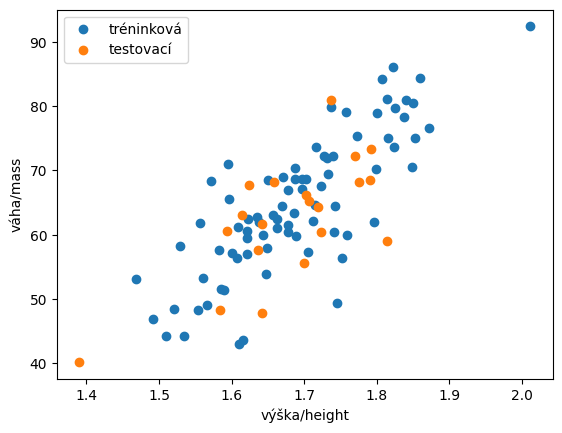

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

def generuj_data(n=100):
  vyska = np.random.normal(1.7, 0.1, n)

  bmi = np.random.uniform(20, 25, n)
  bmi = np.clip(bmi, 20, 28)
  vaha = bmi * vyska**2+ np.random.normal(0, 5, n)
  data = pd.DataFrame({'váha': vaha, 'výška': vyska})
  return data

data = generuj_data(100)
#data/=data.max()
train_data, test_data = train_test_split(data, test_size=0.2)

plt.scatter(train_data['výška'], train_data['váha'], label="tréninková")
plt.scatter(test_data['výška'], test_data['váha'], label="testovací")
plt.legend()
plt.ylabel('váha/mass')
plt.xlabel('výška/height')
plt.show()


# Ukázka vlivu složitosti modelu (BIAS VS VARIANCE)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


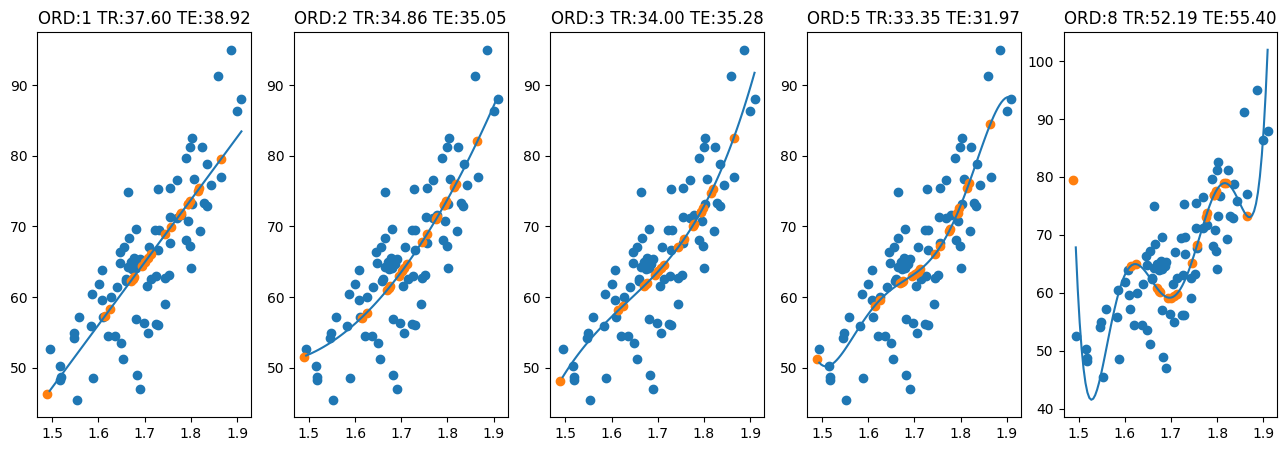

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import numpy.linalg as la

degrees=[1,2,3,5,8]
fig, axes = plt.subplots(1, len(degrees), figsize=(16, 5))
for i, rad in enumerate(degrees):
  poly = PolynomialFeatures(degree=rad) # je tam navic jeste konstantni clen
  X_poly_train = poly.fit_transform(train_data[['výška']].values)
  w = la.solve(X_poly_train.T @ X_poly_train, X_poly_train.T @ train_data['váha']) # resin rovnici X^TX w= X^Tb, kde b= je vaha, kterou predikuji
  y_pred= X_poly_train @ w
  mse_train = np.mean((y_pred - train_data['váha'])**2)
  X_poly_test = poly.fit_transform(test_data[['výška']])
  y_pred_test = X_poly_test @ w
  mse_test = np.mean((y_pred_test - test_data['váha'])**2)
  X_graf = np.linspace(train_data['výška'].min(), train_data['výška'].max(), 100)
  X_graf_poly = poly.transform(X_graf.reshape(-1, 1))

  axes[i].plot(X_graf, X_graf_poly @ w, label="predikce")
  axes[i].scatter(train_data['výška'], train_data['váha'], label="tréninková - realita")
  axes[i].scatter(test_data['výška'], y_pred_test, label="testovací - predikce")
  axes[i].set_title(f"ORD:{rad} TR:{mse_train:.2f} TE:{mse_test:.2f}")
#  axes[i].set_title(f"{rad} TR")
 # axes[i].legend()

**Poznámka:**

Výsledky jsou dost citlivé na výběr testovacích dat. Správně by se měla udělat [křížová validace](https://scikit-learn.org/stable/modules/cross_validation.html).

# Ridge regrese

Místo $\min ||Xw-y||^2$ minimalizuji $||Xw-y||^2+λ||w||^2$.
Toto lze získat analyticky pomocí řešení rovnic (tzv. Tikhonovova regularizace):
$(X^TX+\lambda I)w=X^Ty$

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist

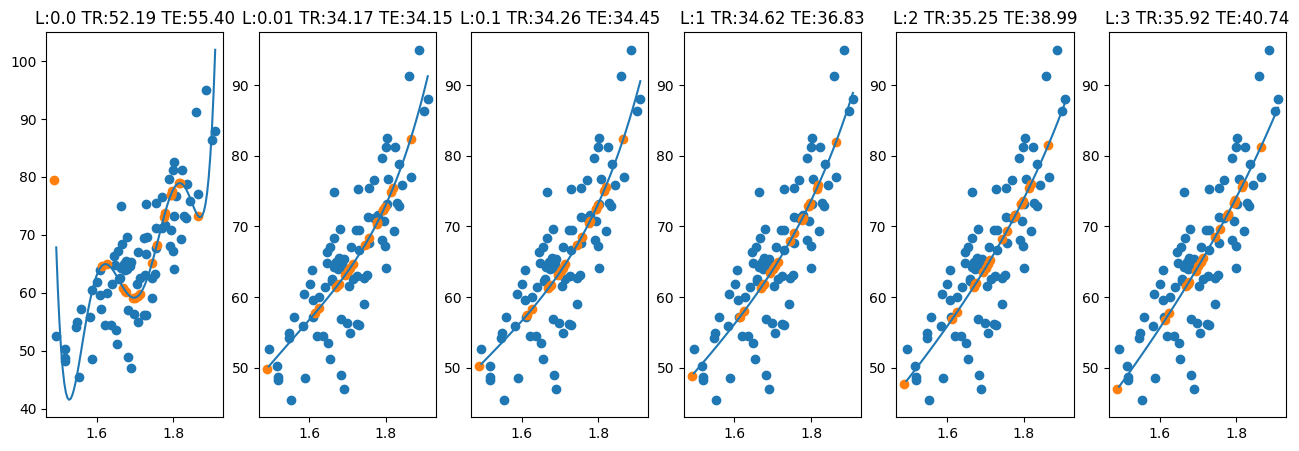

In [ ]:
poly = PolynomialFeatures(degree=max(degrees))
lambdas = [0.0,0.01,0.1,1,2,3]
fig, axes = plt.subplots(1, len(lambdas), figsize=(16, 5))
for i,lam in enumerate(lambdas):
  X_poly_train = poly.fit_transform(train_data[['výška']])
  dim=X_poly_train.shape[1]
  # ZDE je pouzito T. regularizace
  w = la.solve(X_poly_train.T @ X_poly_train+lam*np.eye(dim), X_poly_train.T @ train_data['váha']) # resin rovnici X^TX w= X^Tb, kde b= je vaha, kterou predikuji
  y_pred= X_poly_train @ w
  y_pred = X_poly_train @ w
  mse_train = np.mean((y_pred - train_data['váha'])**2)

  X_poly_test = poly.fit_transform(test_data[['výška']])
  y_pred_test = X_poly_test @ w
  mse_test = np.mean((y_pred_test - test_data['váha'])**2)
  X_graf = np.linspace(train_data['výška'].min(), train_data['výška'].max(), 100)
  X_graf_poly = poly.transform(X_graf.reshape(-1, 1))

  axes[i].plot(X_graf, X_graf_poly @ w, label="predikce")
  axes[i].scatter(train_data['výška'], train_data['váha'], label="tréninková - realita")
  axes[i].scatter(test_data['výška'], y_pred_test, label="testovací - predikce")
  axes[i].set_title(f"L:{lam} TR:{mse_train:.2f} TE:{mse_test:.2f}")
